# C — Planetary Source Analysis: Material Composition Tracing

This notebook reconstructs the source compositions of planetary bodies 
by tracing collision histories and determining fractional contributions from 
different chondritic reservoirs (EF/EC/OC/CI):

**Key steps:**
1. Load N-body simulation snapshots and classify planets by mass (Earth-like: 0.7-1.3 M⊕, Mars-like: 0.05-0.3 M⊕)
2. Identify final planetary bodies at simulation end time
3. Load collision records and filter gas disk phase vs. post-gas disk phase
4. Trace full collision/merger history for each planet using `CollisionTracer`
5. Reconstruct source material distribution across orbital zones
6. Build weighted ECDF (Empirical Cumulative Distribution Function) for each planet
7. Compute cumulative mass fractions at boundary semi-major axes (a = 1.0, 1.3, 3.0 AU)
8. Convert cumulative fractions to absolute chondrite type fractions (EF/EC/OC/CI)
9. Visualize cumulative source distributions and composition pie charts
10. Export planetary source inventory to CSV

**Output:** `./Tables/{Model}_source.csv`

> **Prerequisites:**
> - N-body dataset available at `./N_body_dataset/{model}/` with `aei*.txt` and `Collision*.txt` files
> - `accrediff` module with `CollisionTracer`, `WeightedECDF`, `build_pl_source_dict` functions
>
> **Input:** N-body aei snapshots + Collision file  
> **Output:** Planetary inventory with chondrite source fractions [EF, EC, OC, CI]

**Physical Context:**
- **EF (Enstatite Chondrites):** Inner disk (a ≤ 1.0 AU), high-temperature, reduced
- **EC (Enstatite Chondrites):** Transitional (1.0 < a ≤ 1.3 AU)
- **OC (Ordinary Chondrites):** Middle disk (1.3 < a ≤ 3.0 AU)
- **CI (Carbonaceous Chondrites):** Outer disk (a > 3.0 AU), volatile-rich, oxidized

In [1]:
# ============================================================================
# SETUP & CONFIGURATION
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
import sys
import pathlib
import matplotlib.patches as mpatches

sys.path.append('../../src')
import accrediff as ad

# ── Plot style (Nature-style) ────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.linewidth": 1,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": False,
    "ytick.right": False,
    "figure.dpi": 150,
    "xtick.major.size": 8,
    "xtick.minor.size": 5,
    "xtick.major.width": 1.3,
    "xtick.minor.width": 1.0,
})

# ── Color palette ────────────────────────────────────────────────
Colors = {
    'Earth': "#1f77b4",
    'Mars': "#d62728",
    'EF': "#8c564b",
    'EC': "#ff7f0e",
    'OC': "#2ca02c",
    'CI': "#9467bd",
    'UPB_Fe': "#e377c2",
    'UPB_Mg': "#7f7f7f",
}

# ── Model configuration ──────────────────────────────────────────
model_list = ['note_02', 'demo_25', 'demo_32', 'demo_33', 'demo_48', 'demo_53']
# Note: Temporarily excluded 'demo_29', 'demo_39', 'demo_47', 'demo_55'

Model = model_list[0]  # Select model for analysis
base_path = '../dataset/N_body_dataset/'
model_path = os.path.join(base_path, Model)

print("✅ Setup complete.")
print(f"Model              : {Model}")
print(f"Color palette      : EF={Colors['EF']}, EC={Colors['EC']}, OC={Colors['OC']}, CI={Colors['CI']}")

✅ Setup complete.
Model              : note_02
Color palette      : EF=#8c564b, EC=#ff7f0e, OC=#2ca02c, CI=#9467bd


---
## 1. Load N-body Simulation Data

N-body simulations produce orbital element snapshots at regular time intervals (typically 0.1 Myr).  
Key columns include:
- `t` — simulation time (years)
- `i` — particle index (0 = Jupiter, 1 = Saturn, 2+ = embryos/planetesimals)
- `a`, `e`, `inc` — semi-major axis, eccentricity, inclination
- `m` — mass (solar units, $M_\odot$)

We convert mass to Earth units: $m_e = m / M_\oplus$

**Index:** Particle ID is set as the dataframe index for efficient collision tracing.

In [2]:
# ============================================================================
# SECTION 1: LOAD N-BODY SNAPSHOTS
# ============================================================================

# ── Locate and load all aei files ────────────────────────────────
if not os.path.exists(model_path):
    raise FileNotFoundError(f"Model path {model_path} not found")

file_paths = sorted([
    os.path.join(model_path, f) for f in os.listdir(model_path) 
    if f.startswith('aei')
])

if not file_paths:
    raise FileNotFoundError(f"No aei files found in {model_path}")

# ── Create time keys based on actual file count ──────────────────
# ✅ Key fix: Generate keys from actual file count to avoid KeyError
keys = [f'{i/10:.1f} Myr' for i in range(len(file_paths))]
time_end = keys[-1]  # Final simulation time

# ── Load all snapshots into dictionary ────────────────────────────
col_names = ['t', 'i', 'a', 'e', 'inc', 'Omega', 'w', 'T', 'E', 'M', 'm', 'r']
A_dict = {}

for path, key in zip(file_paths, keys):
    A_dict[key] = pd.read_csv(
        path, sep=' ', header=None, names=col_names, index_col='i'
    )
    # Convert mass to Earth units
    A_dict[key]['m_e'] = A_dict[key]['m'] / ad.constants.ME
    A_dict[key]['N'] = len(A_dict[key])  # Particle count at this snapshot

print(f"✓ Loaded {len(A_dict)} snapshots")
print(f"  Time range    : {keys[0]:>6s} → {time_end:>6s}")
print(f"  Snapshot interval: {(float(keys[1].split()[0]) - float(keys[0].split()[0])):.1f} Myr")
print()

✓ Loaded 1001 snapshots
  Time range    : 0.0 Myr → 100.0 Myr
  Snapshot interval: 0.1 Myr



---
## 2. Identify and Classify Planetary Bodies

At the final simulation time, we filter the N-body population into distinct 
planetary categories based on mass:

**Classification scheme:**
- **Earth-like:** $0.7 M_\oplus \leq m < 1.3 M_\oplus$
- **Mars-like:** $0.05 M_\oplus \leq m < 0.3 M_\oplus$
- **Others:** Unclassified bodies (excluded from analysis)

Giant planets (Jupiter & Saturn, indices 0 & 1) are excluded.

In [3]:
# ============================================================================
# SECTION 2: IDENTIFY AND CLASSIFY PLANETS
# ============================================================================

# ── Get final snapshot and classify bodies ───────────────────────
df_end = A_dict[time_end][['a', 'e', 'inc', 'm_e']].iloc[2:]  # Exclude giants

# ── Vectorized classification by mass ────────────────────────────
conditions = [
    df_end['m_e'].between(0.7, 1.3, inclusive='both'),   # Earth-like
    df_end['m_e'].between(0.05, 0.3, inclusive='both'),  # Mars-like
]
choices = ['Earth_like', 'Mars_like']
df_end['Class'] = np.select(conditions, choices, default='others')

# ── Filter and sort planets by mass ──────────────────────────────
df_planets = (
    df_end[df_end['Class'].isin(['Earth_like', 'Mars_like'])]
    .sort_values(by='m_e', ascending=False)
)
planets_index = df_planets.index.tolist()

# ── Generate unique planet keys (e.g., Earth_like_1, Mars_like_2) ──
# ✅ Avoids dictionary key collisions when multiple planets in same class
class_counter = {}
keys_planets = []
for cls in df_planets['Class']:
    class_counter[cls] = class_counter.get(cls, 0) + 1
    keys_planets.append(f"{cls}_{class_counter[cls]}")

# ── Extract indices by class ─────────────────────────────────────
Earth_like_index = df_planets[df_planets['Class'] == 'Earth_like'].index.tolist()
Mars_like_index = df_planets[df_planets['Class'] == 'Mars_like'].index.tolist()

# ── Summary output ───────────────────────────────────────────────
print(f"✓ Final planets identified at t = {time_end}:")
print(f"  Total planets (m ∈ [0.05, 0.3] or [0.7, 1.3] M⊕) : {len(planets_index)}")
print(f"  Earth-like (m ∈ [0.7, 1.3] M⊕)  : {len(Earth_like_index)} → {Earth_like_index}")
print(f"  Mars-like (m ∈ [0.05, 0.3] M⊕)   : {len(Mars_like_index)} → {Mars_like_index}")
print()
print(f"✓ Planet keys (unique identifiers):")
for i, (key, idx) in enumerate(zip(keys_planets, planets_index)):
    mass = df_planets.loc[idx, 'm_e']
    print(f"  {i+1}. {key:15s} (index={idx:3d}, m={mass:.3f} M⊕)")
print()

✓ Final planets identified at t = 100.0 Myr:
  Total planets (m ∈ [0.05, 0.3] or [0.7, 1.3] M⊕) : 2
  Earth-like (m ∈ [0.7, 1.3] M⊕)  : 1 → [4189]
  Mars-like (m ∈ [0.05, 0.3] M⊕)   : 1 → [4755]

✓ Planet keys (unique identifiers):
  1. Earth_like_1    (index=4189, m=0.842 M⊕)
  2. Mars_like_1     (index=4755, m=0.082 M⊕)



---
## 3. Load and Filter Collision Records

Collision records contain all merger events from the simulation, with particle 
masses, spatial coordinates, and velocities.

**Key filtering:**
- **Gas disk phase:** t ≤ $t_{gas}$ (typically 1-5 Myr, defined by simulation)
- **Post-gas disk phase:** t > $t_{gas}$ (captures late-stage accretion)

We focus on **post-gas disk collisions** to trace the final planet assembly.

In [4]:
# ============================================================================
# SECTION 3: LOAD AND FILTER COLLISION RECORDS
# ============================================================================

# ── Locate collision file ────────────────────────────────────────
collision_files = [
    os.path.join(model_path, f) for f in os.listdir(model_path) 
    if f.startswith('Collision')
]

if not collision_files:
    raise FileNotFoundError(f"No Collision file found in {model_path}")

# ── Load collision data ──────────────────────────────────────────
col_names_c = [
    'time',
    'indexi', 'mi', 'ri', 'xi', 'yi', 'zi', 'vxi', 'vyi', 'vzi', 'Sxi', 'Syi', 'Szi',
    'indexj', 'mj', 'rj', 'xj', 'yj', 'zj', 'vxj', 'vyj', 'vzj', 'Sxj', 'Syj', 'Szj',
]

try:
    C_data = pd.read_csv(collision_files[0], sep=r'\s+', header=None, names=col_names_c)
    C_data['m_ei'] = C_data['mi'] / ad.constants.ME
    C_data['m_ej'] = C_data['mj'] / ad.constants.ME
except Exception as e:
    raise ValueError(f"Failed to read collision file: {e}")

# ── Filter: post-gas disk phase (t > t_gas) ─────────────────────
# ✅ Extract gas time from first snapshot (t=0.0 Myr)
gas_time_yr = A_dict[keys[0]]['t'].iloc[0]
C_nogas = C_data[C_data['time'] > gas_time_yr].copy()

# ── Resolve product IDs and sort by time ─────────────────────────
C_nogas.loc[:, 'product_id'] = C_nogas.apply(ad.resolve_product_id, axis=1)
collision_df = C_nogas[['time', 'indexi', 'm_ei', 'indexj', 'm_ej', 'product_id']].sort_values(
    by='time', ascending=True
)

# ── Summary statistics ───────────────────────────────────────────
print(f"✓ Collision records loaded and filtered:")
print(f"  Gas disk phase end time : {gas_time_yr/1e6:.1f} Myr")
print(f"  Total collisions (all time) : {len(C_data)}")
print(f"  Post-gas disk collisions    : {len(collision_df)}")
print(f"  Time range (post-gas)       : {collision_df['time'].min()/1e6:.2f} - {collision_df['time'].max()/1e6:.2f} Myr")
print()

✓ Collision records loaded and filtered:
  Gas disk phase end time : 0.0 Myr
  Total collisions (all time) : 5790
  Post-gas disk collisions    : 5790
  Time range (post-gas)       : 0.00 - 96.53 Myr



---
## 4. Trace Collision/Merger Histories

Using the `CollisionTracer` class, we reconstruct the full merger tree for each 
final planet by working backward through collision records to identify all 
contributing parent bodies.

**Methodology:**
1. For each final planet (index), trace through `product_id` chain
2. At each collision step, identify both participants (i, j)
3. Accumulate all contributing particles and their masses
4. Build particle history with time evolution

In [5]:
# ============================================================================
# SECTION 4: TRACE COLLISION HISTORIES FOR ALL PLANETS
# ============================================================================

# ── Initialize collision tracer ──────────────────────────────────
tracer = ad.CollisionTracer(collision_df)

# ── Trace history for each planet ────────────────────────────────
pl_history_dict = {}

for key, planet_idx in zip(keys_planets, planets_index):
    # Trace full merger history backward to initial planetesimals
    history = tracer.trace_full_history(planet_idx)
    
    # Add time in Myr (convert from years)
    history['Time'] = history['time'] / 1e6
    
    # Compute total mass at each collision
    history['Mass'] = history['m_ei'] + history['m_ej']
    
    pl_history_dict[key] = history.copy()

# ── Summary output ───────────────────────────────────────────────
print(f"✓ Collision histories traced for all planets:")
for key in keys_planets:
    n_collisions = len(pl_history_dict[key])
    time_range = (pl_history_dict[key]['Time'].min(), pl_history_dict[key]['Time'].max())
    total_mass = pl_history_dict[key]['Mass'].sum()
    print(f"  {key:15s}: {n_collisions:3d} collision events, t ∈ [{time_range[0]:5.2f}, {time_range[1]:5.2f}] Myr")
print()

✓ Collision histories traced for all planets:
  Earth_like_1   : 1051 collision events, t ∈ [ 0.00, 96.53] Myr
  Mars_like_1    : 100 collision events, t ∈ [ 0.01, 53.39] Myr



---
## 5. Reconstruct Material Source Distribution

Using the `build_pl_source_dict` function, we map each planet's contributing 
materials back to their initial orbital positions. This allows us to compute 
the fractional contribution from each chondritic reservoir.

**Output:** For each planet, a DataFrame with:
- `a` — initial semi-major axis of source planetesimal
- `m_norm` — normalized mass contribution (0-1)
- Enables weighted ECDF computation at boundary orbits

In [6]:
# ============================================================================
# SECTION 5: BUILD SOURCE COMPOSITION DICTIONARY
# ============================================================================

# ── Get initial particle distribution ────────────────────────────
# (Only particles that eventually became planets)
df_initial = A_dict[keys[0]][['a', 'e', 'inc', 'm_e']].iloc[2:]
mask_planets = df_initial.index.isin(planets_index)
df_initial_planets = df_initial[mask_planets]

print(f"✓ Initial planetesimal distribution loaded:")
print(f"  Total bodies at t=0: {len(df_initial)}")
print(f"  Became planets:      {len(df_initial_planets)}")
print()

# ── Build source dictionary using robust function ────────────────
pl_source_dict = ad.build_pl_source_dict(pl_history_dict, df_initial)

# ── Summary: source fractions for first planet ───────────────────
first_planet_key = keys_planets[0]
if first_planet_key in pl_source_dict:
    src = pl_source_dict[first_planet_key]
    print(f"✓ Material sources reconstructed for {len(pl_source_dict)} planets")
    print(f"  Example ({first_planet_key}):")
    print(f"    Contributing particles: {len(src)}")
    print(f"    a range: {src['a'].min():.3f} - {src['a'].max():.3f} AU")
    print(f"    Total normalized mass: {src['m_norm'].sum():.6f}")
print()

✓ Initial planetesimal distribution loaded:
  Total bodies at t=0: 7000
  Became planets:      2

✓ Material sources reconstructed for 2 planets
  Example (Earth_like_1):
    Contributing particles: 1052
    a range: 0.707 - 3.985 AU
    Total normalized mass: 1.000000



---
## 6. Compute Cumulative Mass Fractions at Boundary Orbits

We build weighted Empirical Cumulative Distribution Functions (ECDFs) at the 
orbital boundaries to determine what fraction of each planet came from specific 
chondritic reservoirs:

$$B_1 = F(a=1.0 \text{ AU})$$
$$B_2 = F(a=1.3 \text{ AU})$$
$$B_3 = F(a=3.0 \text{ AU})$$

Then convert to absolute chondrite fractions:
$$X_{\text{EF}} = B_1$$
$$X_{\text{EC}} = B_2 - B_1$$
$$X_{\text{OC}} = B_3 - B_2$$
$$X_{\text{CI}} = 1 - B_3$$

In [7]:
# ============================================================================
# SECTION 6: COMPUTE CHONDRITE FRACTIONS AT BOUNDARY ORBITS
# ============================================================================

# ── Define boundary semi-major axes ──────────────────────────────
boundaries = {'B1': 1.0, 'B2': 1.3, 'B3': 3.0}  # AU
boundary_keys = ['B1', 'B2', 'B3']
boundary_values = [1.0, 1.3, 3.0]

# ── Initialize dataframe for results ────────────────────────────
df_source = df_planets.copy()
df_source[boundary_keys] = np.nan

# ── Create mapping from planet key to particle ID ────────────────
planet_id_map = dict(zip(keys_planets, planets_index))

# ── Compute cumulative fractions for each planet ─────────────────
for planet_key, pl_source_sel in pl_source_dict.items():
    if pl_source_sel.empty:
        print(f"⚠ Warning: {planet_key} has no source data, skipping")
        continue
    
    # Build weighted ECDF from material sources
    ecdf = ad.WeightedECDF(pl_source_sel['a'], pl_source_sel['m_norm'])
    
    # Evaluate ECDF at boundary orbits
    y_vals = ecdf(boundary_values)
    
    # Store in dataframe
    pid = planet_id_map.get(planet_key)
    if pid in df_source.index:
        df_source.loc[pid, boundary_keys] = y_vals

print(f"✓ Cumulative mass fractions computed at boundaries:")
print(f"  a = 1.0 AU (EF/EC boundary) → B1")
print(f"  a = 1.3 AU (EC/OC boundary) → B2")
print(f"  a = 3.0 AU (OC/CI boundary) → B3")
print()

# ── Convert cumulative fractions to chondrite compositions ────────
meteorite_types = ['EF', 'EC', 'OC', 'CI']
df_source['EF'] = df_source['B1']
df_source['EC'] = df_source['B2'] - df_source['B1']
df_source['OC'] = df_source['B3'] - df_source['B2']
df_source['CI'] = 1.0 - df_source['B3']

print(f"✓ Chondrite fractions computed:")
print(df_source[meteorite_types].to_string())
print()

✓ Cumulative mass fractions computed at boundaries:
  a = 1.0 AU (EF/EC boundary) → B1
  a = 1.3 AU (EC/OC boundary) → B2
  a = 3.0 AU (OC/CI boundary) → B3

✓ Chondrite fractions computed:
            EF        EC        OC        CI
i                                           
4189  0.309469  0.401771  0.277122  0.011638
4755  0.192576  0.265605  0.514762  0.027056



---
## 7. Visualize Cumulative Source Distributions

Plot the weighted ECDF for each planet, showing cumulative mass fraction 
as a function of initial orbital distance.

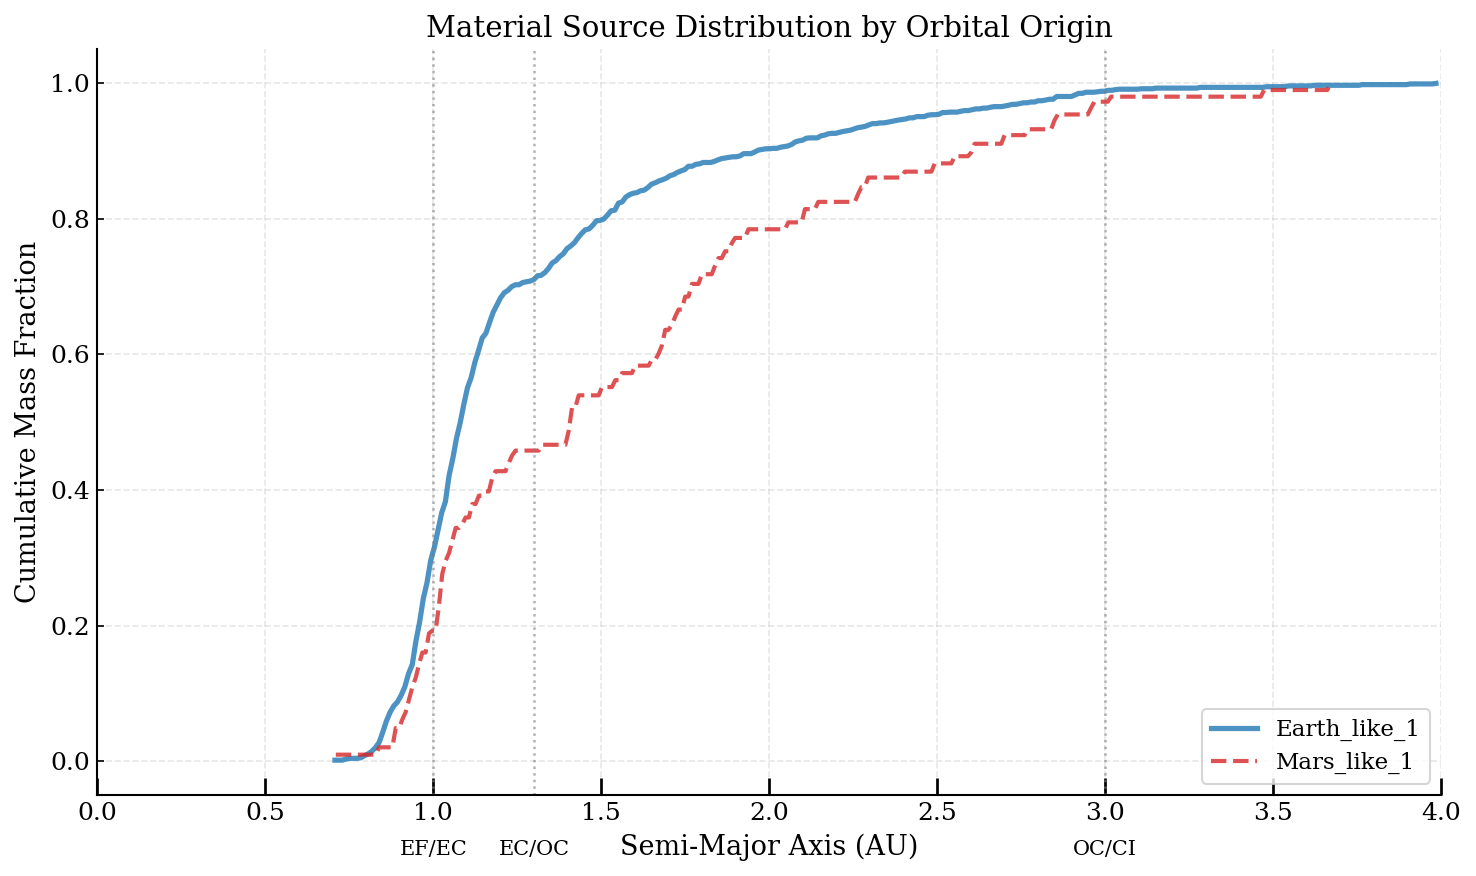

✓ Cumulative ECDF plot generated



In [8]:
# ============================================================================
# SECTION 7: VISUALIZATION - CUMULATIVE SOURCE ECDF
# ============================================================================

fig, ax = plt.subplots(figsize=(10, 6))

for i, (planet_key, pl_source_sel) in enumerate(pl_source_dict.items()):
    if pl_source_sel.empty:
        print(f"⚠ Skipping empty data for {planet_key}")
        continue
    
    # Build weighted ECDF
    ecdf = ad.WeightedECDF(pl_source_sel['a'], pl_source_sel['m_norm'])
    
    # Evaluate over range
    x_vals = np.linspace(pl_source_sel['a'].min(), pl_source_sel['a'].max(), 300)
    y_vals = ecdf(x_vals)
    
    # Determine color by planet class
    if planet_key.startswith('Earth_like'):
        line_color = Colors['Earth']
        linestyle = '-'
        linewidth = 2.5
    elif planet_key.startswith('Mars_like'):
        line_color = Colors['Mars']
        linestyle = '--'
        linewidth = 2.0
    else:
        line_color = f'C{i}'
        linestyle = '-'
        linewidth = 1.5
    
    ax.plot(x_vals, y_vals, color=line_color, linestyle=linestyle, linewidth=linewidth,
            label=planet_key, alpha=0.8)

# ── Add boundary markers ─────────────────────────────────────────
for boundary_val in [1.0, 1.3, 3.0]:
    ax.axvline(boundary_val, linestyle=':', color='gray', linewidth=1.2, alpha=0.6)

ax.text(1.0, -0.08, 'EF/EC', ha='center', fontsize=10, transform=ax.get_xaxis_transform())
ax.text(1.3, -0.08, 'EC/OC', ha='center', fontsize=10, transform=ax.get_xaxis_transform())
ax.text(3.0, -0.08, 'OC/CI', ha='center', fontsize=10, transform=ax.get_xaxis_transform())

# ── Formatting ───────────────────────────────────────────────────
ax.set_xlim(0, 4)
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel('Semi-Major Axis (AU)', fontsize=13)
ax.set_ylabel('Cumulative Mass Fraction', fontsize=13)
ax.set_title(f'Material Source Distribution by Orbital Origin', fontsize=14)
ax.grid(True, alpha=0.3, ls='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=11, loc='lower right', frameon=True)

plt.tight_layout()
plt.show()

print(f"✓ Cumulative ECDF plot generated")
print()

---
## 8. Visualize Planetary Compositions as Pie Charts

Create pie charts showing the fractional contributions from each chondritic 
component (EF/EC/OC/CI) for each planet.

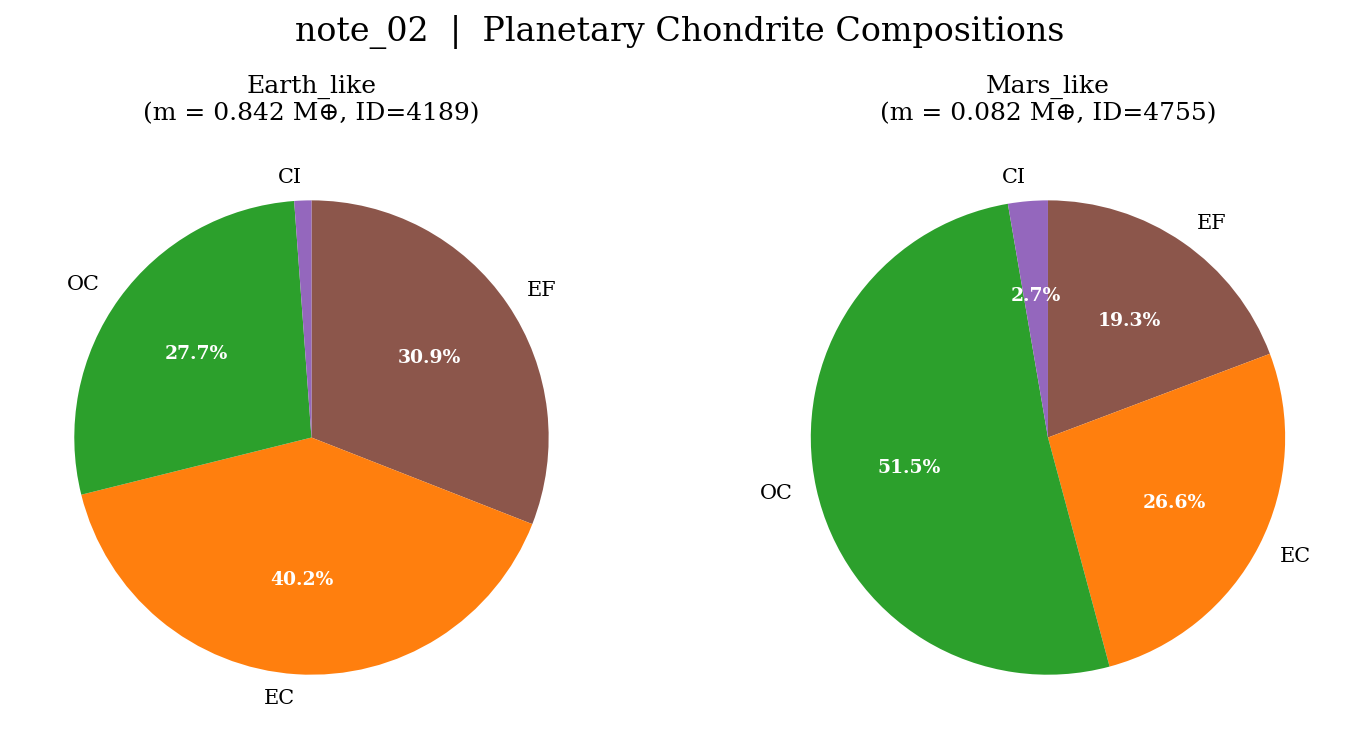

✓ Composition pie charts generated for 2 planets



In [9]:
# ============================================================================
# SECTION 8: VISUALIZATION - COMPOSITION PIE CHARTS
# ============================================================================

# ── Create subplots for all planets ──────────────────────────────
n_planets = len(df_source)
n_cols = min(3, n_planets)
n_rows = (n_planets + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows))

# Handle single subplot case
if n_planets == 1:
    axes = np.array([axes])

axes = axes.flatten()

# ── Plot pie chart for each planet ───────────────────────────────
for idx, (ax, planet_id) in enumerate(zip(axes, df_source.index)):
    # Extract composition values
    labels = ['EF', 'EC', 'OC', 'CI']
    values = df_source.loc[planet_id, labels].astype(float).clip(lower=0).fillna(0).values
    
    # Normalize (should already sum to ~1.0, but ensure)
    total = values.sum()
    if total == 0:
        print(f"⚠ Warning: Planet {planet_id} has zero total composition, skipping")
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        continue
    
    values = values / total
    
    # Get planet class for title
    planet_class = df_planets.loc[planet_id, 'Class']
    planet_mass = df_planets.loc[planet_id, 'm_e']
    
    # Define colors
    pie_colors = [Colors['EF'], Colors['EC'], Colors['OC'], Colors['CI']]
    
    # Create pie chart
    wedges, texts, autotexts = ax.pie(
        values,
        labels=labels,
        colors=pie_colors,
        autopct=lambda p: f'{p:.1f}%' if p > 2 else '',
        startangle=90,
        counterclock=False,
        textprops={'fontsize': 10}
    )
    
    # Enhance autotext (percentage labels)
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(9)
    
    # Title: class and mass
    title = f'{planet_class}\n(m = {planet_mass:.3f} M⊕, ID={planet_id})'
    ax.set_title(title, fontsize=12, pad=10)

# Hide unused subplots
for ax in axes[n_planets:]:
    ax.axis('off')

plt.suptitle(f'{Model}  |  Planetary Chondrite Compositions', fontsize=16, y=0.995)
plt.tight_layout()
plt.show()

print(f"✓ Composition pie charts generated for {n_planets} planets")
print()

---
## 9. Export and Summary

Save the complete planetary source inventory with all composition data 
for downstream analysis.

In [10]:
# ============================================================================
# SECTION 9: EXPORT & SUMMARY
# ============================================================================

# ── Prepare output dataframe ─────────────────────────────────────
# ✅ Select relevant columns for output
output_cols = ['a', 'e', 'inc', 'm_e', 'Class'] + boundary_keys + meteorite_types
df_export = df_source[output_cols].copy()

# ── Export to CSV ────────────────────────────────────────────────
save_dir = pathlib.Path('./Tables')
save_dir.mkdir(parents=True, exist_ok=True)

filename = f'{Model}_source.csv'
save_file = save_dir / filename

df_export.to_csv(save_file)

print(f"✅ Exported: {save_file}")
print(f"  Rows    : {len(df_export)}")
print(f"  Columns : {len(df_export.columns)}")
print()

# Verify export
data_verify = pd.read_csv(save_file, index_col=0)
print(f"✓ CSV verification: {len(data_verify)} planets loaded")
print()

# ── Summary statistics ───────────────────────────────────────────
print("=" * 70)
print("WORKFLOW SUMMARY")
print("=" * 70)
print()
print(f"Model                     : {Model}")
print(f"Simulation end time       : {time_end}")
print(f"N-body snapshots analyzed : {len(A_dict)}")
print()
print(f"Planets identified @ t = {time_end}:")
print(f"  Earth-like (m ∈ [0.7, 1.3] M⊕) : {len(Earth_like_index)}")
print(f"  Mars-like (m ∈ [0.05, 0.3] M⊕)  : {len(Mars_like_index)}")
print(f"  Total                            : {len(df_source)}")
print()
print(f"Collision history:")
print(f"  Gas disk phase events          : {len(C_data) - len(collision_df)}")
print(f"  Post-gas disk phase events     : {len(collision_df)}")
print()
print(f"Chondrite composition statistics (all planets):")
for com_type in meteorite_types:
    mean_frac = df_source[com_type].mean()
    std_frac = df_source[com_type].std()
    print(f"  {com_type}: {mean_frac:.3f} ± {std_frac:.3f}")
print()
print(f"Output file:")
print(f"  {save_file}")
print()
print("=" * 70)
print("✅ Workflow complete. Planetary source analysis ready for publication.")
print("=" * 70)

✅ Exported: Tables/note_02_source.csv
  Rows    : 2
  Columns : 12

✓ CSV verification: 2 planets loaded

WORKFLOW SUMMARY

Model                     : note_02
Simulation end time       : 100.0 Myr
N-body snapshots analyzed : 1001

Planets identified @ t = 100.0 Myr:
  Earth-like (m ∈ [0.7, 1.3] M⊕) : 1
  Mars-like (m ∈ [0.05, 0.3] M⊕)  : 1
  Total                            : 2

Collision history:
  Gas disk phase events          : 0
  Post-gas disk phase events     : 5790

Chondrite composition statistics (all planets):
  EF: 0.251 ± 0.083
  EC: 0.334 ± 0.096
  OC: 0.396 ± 0.168
  CI: 0.019 ± 0.011

Output file:
  Tables/note_02_source.csv

✅ Workflow complete. Planetary source analysis ready for publication.
